In [1]:
import pandas as pd


In [2]:
ratings = pd.read_csv("../data/ratings.dat", sep="::", engine="python",
names=["UserID","MovieID","Rating","Timestamp"], encoding="latin-1")

movies = pd.read_csv("../data/movies.dat", sep="::", engine="python",
names=["MovieID","Title","Genres"], encoding="latin-1")

users = pd.read_csv("../data/users.dat", sep="::", engine="python",
names=["UserID","Gender","Age","Occupation","Zip-code"], encoding="latin-1")

In [3]:
ratings.shape


(1000209, 4)

In [4]:

users.shape

(6040, 5)

In [5]:
movies.shape


(3883, 3)

In [6]:
ratings.columns

Index(['UserID', 'MovieID', 'Rating', 'Timestamp'], dtype='object')

In [7]:
movies.columns


Index(['MovieID', 'Title', 'Genres'], dtype='object')

In [8]:
users.columns

Index(['UserID', 'Gender', 'Age', 'Occupation', 'Zip-code'], dtype='object')

In [9]:
ratings.dtypes


UserID       int64
MovieID      int64
Rating       int64
Timestamp    int64
dtype: object

In [10]:
movies.dtypes


MovieID     int64
Title      object
Genres     object
dtype: object

In [11]:
users.dtypes

UserID         int64
Gender        object
Age            int64
Occupation     int64
Zip-code      object
dtype: object

In [12]:
ratings.isnull().sum()


UserID       0
MovieID      0
Rating       0
Timestamp    0
dtype: int64

In [13]:
movies.isnull().sum()


MovieID    0
Title      0
Genres     0
dtype: int64

In [14]:
users.isnull().sum()

UserID        0
Gender        0
Age           0
Occupation    0
Zip-code      0
dtype: int64

In [15]:
ratings.describe()

,UserID,MovieID,Rating,Timestamp
count,1.000209e+06,1.000209e+06,1.000209e+06,1.000209e+06
mean,3.024512e+03,1.865540e+03,3.581564e+00,9.722437e+08
std,1.728413e+03,1.096041e+03,1.117102e+00,1.215256e+07
min,1.000000e+00,1.000000e+00,1.000000e+00,9.567039e+08
25%,1.506000e+03,1.030000e+03,3.000000e+00,9.653026e+08
50%,3.070000e+03,1.835000e+03,4.000000e+00,9.730180e+08
75%,4.476000e+03,2.770000e+03,4.000000e+00,9.752209e+08
max,6.040000e+03,3.952000e+03,5.000000e+00,1.046455e+09


In [16]:
ratings['Rating'].value_counts()

Rating
4    348971
3    261197
5    226310
2    107557
1     56174
Name: count, dtype: int64

In [17]:
ratings['UserID'].nunique()


6040

In [18]:
ratings['MovieID'].nunique()

3706

In [19]:
ratings.groupby('UserID')['Rating'].count().describe()

count    6040.000000
mean      165.597517
std       192.747029
min        20.000000
25%        44.000000
50%        96.000000
75%       208.000000
max      2314.000000
Name: Rating, dtype: float64

In [20]:
ratings.groupby('MovieID')['Rating'].count().describe()

count    3706.000000
mean      269.889099
std       384.047838
min         1.000000
25%        33.000000
50%       123.500000
75%       350.000000
max      3428.000000
Name: Rating, dtype: float64

In [21]:
ratings.groupby('MovieID')['Rating'].count().sort_values(ascending=False).head(10)

MovieID
2858    3428
260     2991
1196    2990
1210    2883
480     2672
2028    2653
589     2649
2571    2590
1270    2583
593     2578
Name: Rating, dtype: int64

In [22]:
ratings.groupby('MovieID')['Rating'].mean().sort_values(ascending=False).head(10)

MovieID
989     5.0
3881    5.0
1830    5.0
3382    5.0
787     5.0
3280    5.0
3607    5.0
3233    5.0
3172    5.0
3656    5.0
Name: Rating, dtype: float64

In [23]:
movie_stats = ratings.groupby('MovieID')['Rating'].agg(['count','mean'])
movie_stats[movie_stats['count'] > 100].sort_values('mean', ascending=False).head(10)

,count,mean
MovieID,,
2019,628,4.560510
318,2227,4.554558
858,2223,4.524966
745,657,4.520548
50,1783,4.517106
527,2304,4.510417
1148,882,4.507937
922,470,4.491489
1198,2514,4.477725


### Advanced EDA


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

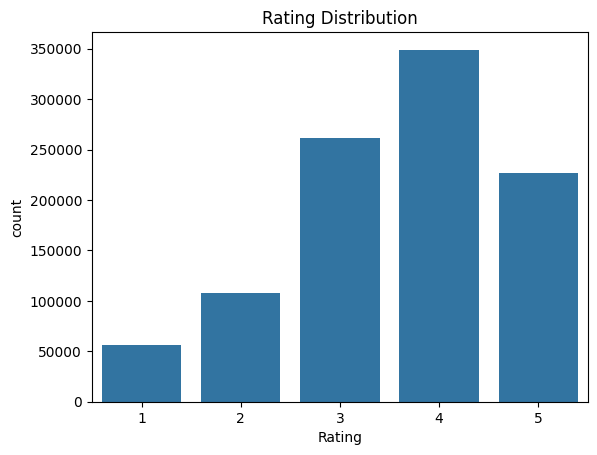

In [25]:
sns.countplot(x='Rating', data=ratings)
plt.title("Rating Distribution")
plt.show()

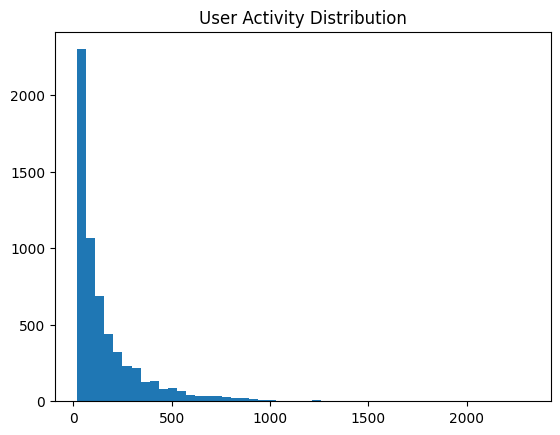

In [26]:
ratings_per_user = ratings.groupby('UserID')['Rating'].count()

plt.hist(ratings_per_user, bins=50)
plt.title("User Activity Distribution")
plt.show()

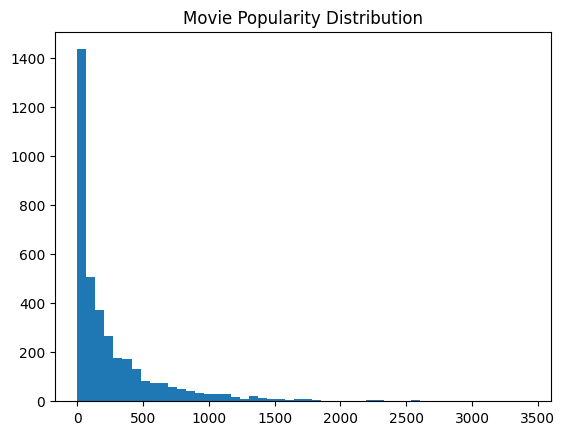

In [27]:
ratings_per_movie = ratings.groupby('MovieID')['Rating'].count()

plt.hist(ratings_per_movie, bins=50)
plt.title("Movie Popularity Distribution")
plt.show()

In [28]:
ratings['Timestamp'] = pd.to_datetime(ratings['Timestamp'], unit='s')
ratings['Timestamp'].head()

0   2000-12-31 22:12:40
1   2000-12-31 22:35:09
2   2000-12-31 22:32:48
3   2000-12-31 22:04:35
4   2001-01-06 23:38:11
Name: Timestamp, dtype: datetime64[ns]

In [29]:
ratings['year'] = ratings['Timestamp'].dt.year
ratings['year'].value_counts().sort_index()

year
2000    904757
2001     68058
2002     24046
2003      3348
Name: count, dtype: int64

In [30]:
ratings.merge(movies, on="MovieID").head()

,UserID,MovieID,Rating,Timestamp,year,Title,Genres
0,1,1193,5,2000-12-31 22:12:40,2000,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,2000-12-31 22:35:09,2000,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,2000-12-31 22:32:48,2000,My Fair Lady (1964),Musical|Romance
3,1,3408,4,2000-12-31 22:04:35,2000,Erin Brockovich (2000),Drama
4,1,2355,5,2001-01-06 23:38:11,2001,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [31]:
ratings.merge(movies, on="MovieID")['Genres'].value_counts().head(10)

Genres
Comedy                     116883
Drama                      111423
Comedy|Romance              42712
Comedy|Drama                42245
Drama|Romance               29170
Action|Thriller             26759
Horror                      22563
Drama|Thriller              18248
Thriller                    17851
Action|Adventure|Sci-Fi     17783
Name: count, dtype: int64

In [32]:
ratings.merge(movies, on="MovieID")['Genres'].value_counts().head(10)

Genres
Comedy                     116883
Drama                      111423
Comedy|Romance              42712
Comedy|Drama                42245
Drama|Romance               29170
Action|Thriller             26759
Horror                      22563
Drama|Thriller              18248
Thriller                    17851
Action|Adventure|Sci-Fi     17783
Name: count, dtype: int64